**Name:** Devyani Sanjay Gurgude **Div**: SEDA **Roll:** 09 **PRN no**:1252090009

**Assignment No:08**

Apply appropriate ML algorithm on a dataset collected in a cosmetics shop showing details of customers to predict customer response for special offer. Create confusion matrix based on above data and find:

Accuracy

Precision

Recall

F-1 score

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

data = {
    'Age': [22, 45, 30, 35, 50, 23, 40, 29, 33, 48],
    'Salary': [25000, 50000, 32000, 40000, 60000, 27000, 52000, 31000, 38000, 58000],
    'Discount': [10, 5, 15, 10, 5, 20, 5, 15, 10, 5],
    'Rating': [5, 3, 4, 5, 2, 4, 3, 5, 4, 2],
    'Total_Feedback': [10, 5, 7, 12, 3, 8, 6, 11, 7, 4],
    'Price_USD': [20, 45, 30, 25, 50, 22, 40, 28, 35, 48],
    'Purchased': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)
print(df)

   Age  Salary  Discount  Rating  Total_Feedback  Price_USD  Purchased
0   22   25000        10       5              10         20          1
1   45   50000         5       3               5         45          0
2   30   32000        15       4               7         30          1
3   35   40000        10       5              12         25          1
4   50   60000         5       2               3         50          0
5   23   27000        20       4               8         22          1
6   40   52000         5       3               6         40          0
7   29   31000        15       5              11         28          1
8   33   38000        10       4               7         35          1
9   48   58000         5       2               4         48          0


Logistic Regression(Single Feature)

In [ ]:
X = df[['Age']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
 [[1 0]
 [0 2]]


Logistic Regression(Multiple Feature)

In [ ]:
X = df[['Age', 'Salary', 'Discount', 'Rating', 'Total_Feedback', 'Price_USD']]
y = df['Purchased']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))


Confusion Matrix:
 [[1 0]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



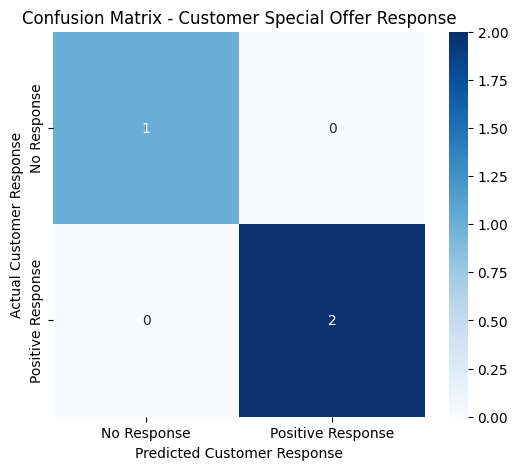

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Response", "Positive Response"],
            yticklabels=["No Response", "Positive Response"])
plt.xlabel("Predicted Customer Response")
plt.ylabel("Actual Customer Response")
plt.title("Confusion Matrix - Customer Special Offer Response")
plt.show()

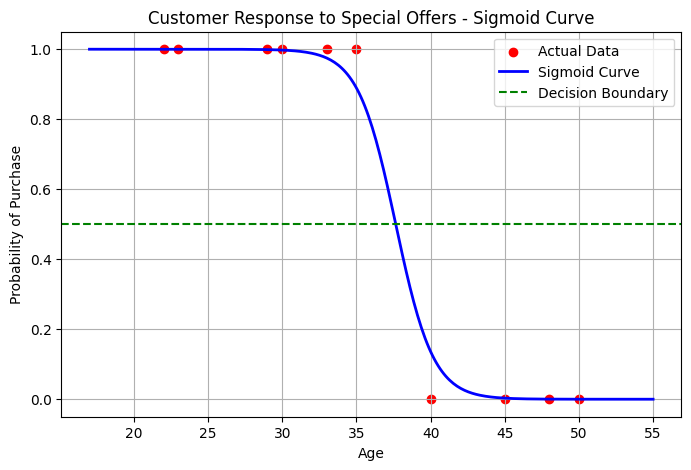

Decision Boundary (Age): 37.64947536245929


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import pandas as pd

data = {
    'Age': [22, 45, 30, 35, 50, 23, 40, 29, 33, 48],
    'Salary': [25000, 50000, 32000, 40000, 60000, 27000, 52000, 31000, 38000, 58000],
    'Discount': [10, 5, 15, 10, 5, 20, 5, 15, 10, 5],
    'Rating': [5, 3, 4, 5, 2, 4, 3, 5, 4, 2],
    'Total_Feedback': [10, 5, 7, 12, 3, 8, 6, 11, 7, 4],
    'Price_USD': [20, 45, 30, 25, 50, 22, 40, 28, 35, 48],
    'Purchased': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

X = df[['Age']].values
y = df['Purchased'].values

model = LogisticRegression()
model.fit(X, y)

X_test = np.linspace(df['Age'].min()-5, df['Age'].max()+5, 300).reshape(-1, 1)
y_prob = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8,5))
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X_test, y_prob, color='blue', linewidth=2, label='Sigmoid Curve')
plt.axhline(0.5, color='green', linestyle='--', label='Decision Boundary')
plt.title("Customer Response to Special Offers - Sigmoid Curve")
plt.xlabel("Age")
plt.ylabel("Probability of Purchase")
plt.legend()
plt.grid(True)
plt.show()

b0 = model.intercept_[0]
b1 = model.coef_[0][0]
decision_boundary = -b0 / b1

print("Decision Boundary (Age):", decision_boundary)

User Defined Functions for Performance Metrics

In [ ]:
def my_accuracy(TP, TN, FP, FN):
    return (TP + TN) / (TP + TN + FP + FN)

In [ ]:
def my_precision(TP, FP):
    return TP / (TP + FP)

In [ ]:
def my_recall(TP, FN):
    return TP / (TP + FN)

In [ ]:
def my_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall)

In [ ]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

acc = my_accuracy(TP, TN, FP, FN)
prec = my_precision(TP, FP)
rec = my_recall(TP, FN)
f1 = my_f1(prec, rec)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


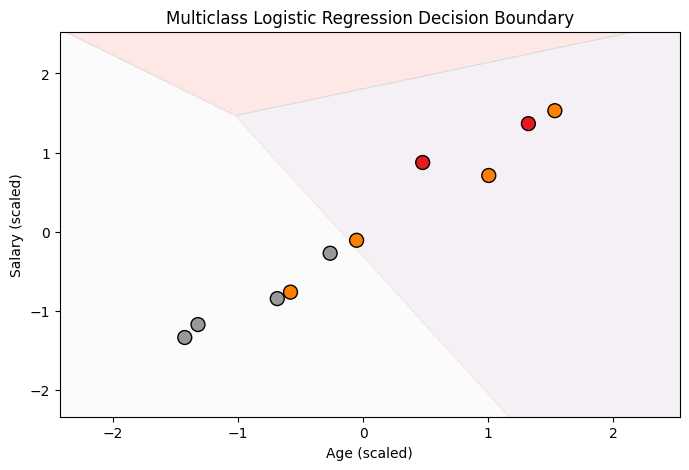

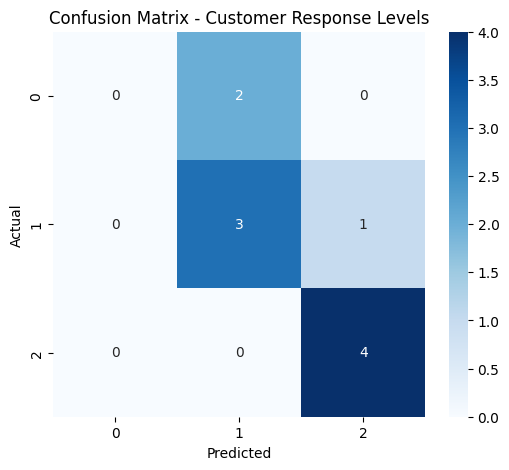

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

data = {
    'Age': [22, 45, 30, 35, 50, 23, 40, 29, 33, 48],
    'Salary': [25000, 50000, 32000, 40000, 60000, 27000, 52000, 31000, 38000, 58000],
    'Purchased': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

df['Response_Level'] = df['Purchased'] + np.random.choice([0,1], size=len(df))
df['Response_Level'] = df['Response_Level'].clip(0,2)  # Ensure values in [0,2]

X = df[['Age', 'Salary']].values
y = df['Response_Level'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(multi_class='ovr')
model.fit(X_scaled, y)

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=100, edgecolor='k', cmap='Set1')
plt.xlabel("Age (scaled)")
plt.ylabel("Salary (scaled)")
plt.title("Multiclass Logistic Regression Decision Boundary")
plt.show()

y_pred = model.predict(X_scaled)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Customer Response Levels")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()